# Grover's Search Algorithm
### $O(\sqrt{N})$ quantum search over $N$ unstructured items

**Course:** UCL Quantum Computing · **Prerequisites:** Hadamard, phase kickback, Deutsch-Jozsa

---

## The Search Problem

Given an unstructured database of $N = 2^n$ items, find the one marked item.
There is no structure to exploit — you can only query "is this item the target?".

| | Queries needed |
|---|---|
| Classical (deterministic) | $N$ worst case |
| Classical (randomised) | $N/2$ on average |
| **Grover's algorithm** | $\approx \frac{\pi}{4}\sqrt{N}$ — provably optimal for quantum |

For $N = 2^{20} \approx 10^6$: classical needs 500,000 queries; Grover needs ~800.
For $N = 2^{40}$: classical needs $10^{12}$; Grover needs ~1 million.
This is a **quadratic speedup** — significant but not exponential like Shor's.


## The Core Idea: Amplitude Amplification

Start with a uniform superposition over all $N$ states. The target state $|\omega\rangle$ has amplitude $1/\sqrt{N}$ — tiny.

Grover's algorithm **amplifies** the target amplitude while suppressing all others, using two operations repeated $k \approx \frac{\pi}{4}\sqrt{N}$ times:

1. **Oracle** $U_\omega$: flips the sign (phase) of the target state only.
   $U_\omega|x\rangle = -|x\rangle$ if $x = \omega$, else $|x\rangle$.

2. **Diffusion** $D$ (Grover diffusion / inversion about average):
   $D = 2|s\rangle\langle s| - I$ where $|s\rangle = H^{\otimes n}|0\rangle^{\otimes n}$ is the uniform superposition.
   This reflects all amplitudes about their average — boosting whatever the oracle boosted.

**Geometric picture**: the state lives in the 2D space spanned by $|\omega\rangle$ and $|\omega^\perp\rangle$.
Each oracle + diffusion step rotates the state vector by $2\theta$ toward $|\omega\rangle$,
where $\sin\theta = 1/\sqrt{N}$. After $k$ steps, the angle from $|\omega\rangle$ is $\frac{\pi}{2} - (2k+1)\theta$.
Optimal: stop when $(2k+1)\theta \approx \pi/2$, giving $k \approx \frac{\pi}{4\theta} \approx \frac{\pi}{4}\sqrt{N}$.


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})
simulator = AerSimulator()
print("Ready ✓")


Ready ✓


In [2]:
# ── Phase Oracle ────────────────────────────────────────────────────
def phase_oracle(n, target):
    """
    Marks target state |target⟩ with a phase flip: |target⟩ → −|target⟩
    target: integer (0 to 2^n - 1) or binary string like '101'
    """
    qc = QuantumCircuit(n, name=f"Oracle |{target}⟩")

    if isinstance(target, int):
        target = format(target, f'0{n}b')

    # Flip qubits where target bit is '0'
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z (= H · MCX · H on last qubit)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Undo the bit flips
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)

    return qc

# Test: show oracle for |101⟩ on 3 qubits
oracle = phase_oracle(3, '101')
print(oracle.draw('text'))
print("\nOracle marks state |101⟩ with a phase flip.")


                    
q_0: ───────■───────
     ┌───┐  │  ┌───┐
q_1: ┤ X ├──■──┤ X ├
     ├───┤┌─┴─┐├───┤
q_2: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

Oracle marks state |101⟩ with a phase flip.


In [3]:
# ── Grover Diffusion Operator ────────────────────────────────────────
def grover_diffusion(n):
    """
    Grover diffusion = inversion about the uniform superposition |s⟩.
    D = H^n · (2|0⟩⟨0| - I) · H^n
      = H^n · X^n · (MCZ) · X^n · H^n
    """
    qc = QuantumCircuit(n, name="Diffusion")

    qc.h(range(n))
    qc.x(range(n))

    # Multi-controlled Z
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    qc.x(range(n))
    qc.h(range(n))

    return qc

print("Diffusion operator (3 qubits):")
print(grover_diffusion(3).draw('text'))


Diffusion operator (3 qubits):
     ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘


In [4]:
# ── Full Grover Circuit ──────────────────────────────────────────────
def grover_circuit(n, target, iterations=None):
    """
    Full Grover search circuit.
    n: number of qubits  (searches 2^n items)
    target: binary string e.g. '101'
    iterations: number of oracle+diffusion steps (auto if None)
    """
    N = 2 ** n
    if iterations is None:
        iterations = max(1, int(np.round(np.pi / 4 * np.sqrt(N))))

    qc = QuantumCircuit(n, n)

    # ① Uniform superposition
    qc.h(range(n))
    qc.barrier()

    # ② Grover iterations
    oracle = phase_oracle(n, target)
    diffusion = grover_diffusion(n)

    for step in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)
        qc.barrier()

    # ③ Measure
    qc.measure(range(n), range(n))
    return qc

# Build and show circuit for n=3, target=|101⟩, 2 iterations
qc = grover_circuit(3, '101', iterations=2)
print(f"Grover circuit: n=3, target=|101⟩, iterations=2")
print(f"Total gates (without barriers): {qc.size()}")
print(qc.draw('text'))


Grover circuit: n=3, target=|101⟩, iterations=2
Total gates (without barriers): 46
     ┌───┐ ░           ┌───┐┌───┐               ┌───┐┌───┐      ░           »
q_0: ┤ H ├─░────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────░────────■──»
     ├───┤ ░ ┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤      ░ ┌───┐  │  »
q_1: ┤ H ├─░─┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├──────░─┤ X ├──■──»
     ├───┤ ░ ├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐ ░ ├───┤┌─┴─┐»
q_2: ┤ H ├─░─┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├─░─┤ H ├┤ X ├»
     └───┘ ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘ ░ └───┘└───┘»
c: 3/═══════════════════════════════════════════════════════════════════════»
                                                                            »
«     ┌───┐┌───┐               ┌───┐┌───┐      ░ ┌─┐      
«q_0: ┤ H ├┤ X ├────────────■──┤ X ├┤ H ├──────░─┤M├──────
«     ├───┤├───┤┌───┐       │  ├───┤├───┤      ░ └╥┘┌─┐   
«q_1: ┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ 

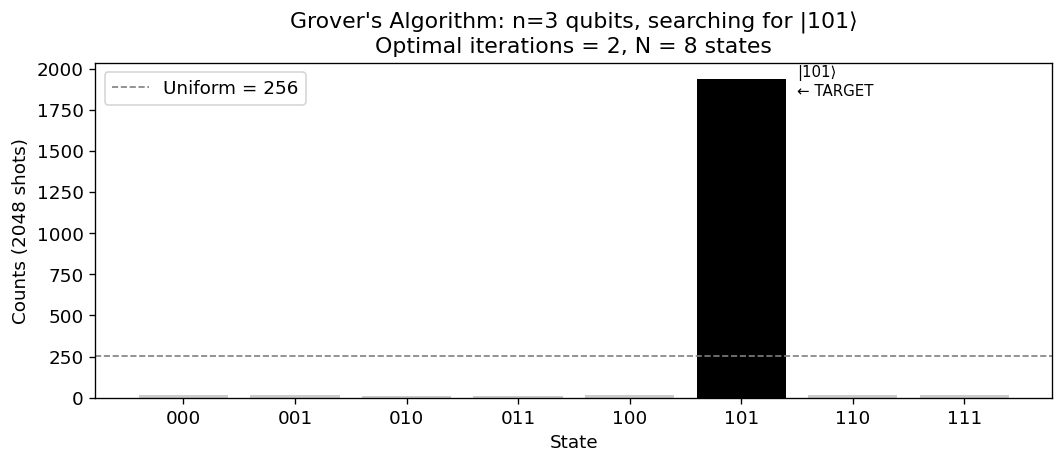


Target |101⟩ measured 1938 / 2048 times
Success probability: 94.6%
Expected (classical random): 12.5%
Speedup: ~2×  (avg classical / Grover iterations)


In [5]:
# ── Run Grover search and visualise ─────────────────────────────────
n, target = 3, '101'
N = 2 ** n
opt_iters = max(1, int(np.round(np.pi / 4 * np.sqrt(N))))

qc = grover_circuit(n, target, iterations=opt_iters)
t_qc = transpile(qc, simulator)
result = simulator.run(t_qc, shots=2048).result()
counts = result.get_counts()

# Sort for clean plot
all_states = [format(i, f'0{n}b') for i in range(N)]
values = [counts.get(s, 0) for s in all_states]
colors = ['#000' if s == target else '#ccc' for s in all_states]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(all_states, values, color=colors)
ax.set_xlabel("State")
ax.set_ylabel("Counts (2048 shots)")
ax.set_title(f"Grover's Algorithm: n={n} qubits, searching for |{target}⟩\n"
             f"Optimal iterations = {opt_iters}, N = {N} states")
ax.axhline(2048/N, color='gray', ls='--', lw=1, label=f'Uniform = {2048//N}')
ax.legend()

# Annotate target
target_idx = all_states.index(target)
ax.annotate(f'|{target}⟩\n← TARGET', xy=(target_idx, values[target_idx]),
            xytext=(target_idx + 0.5, values[target_idx] - 100),
            fontsize=9, ha='left')

plt.tight_layout()
plt.savefig('grover_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nTarget |{target}⟩ measured {counts.get(target, 0)} / 2048 times")
print(f"Success probability: {counts.get(target, 0) / 2048:.1%}")
print(f"Expected (classical random): {1/N:.1%}")
print(f"Speedup: ~{(N/2) / opt_iters:.0f}×  (avg classical / Grover iterations)")


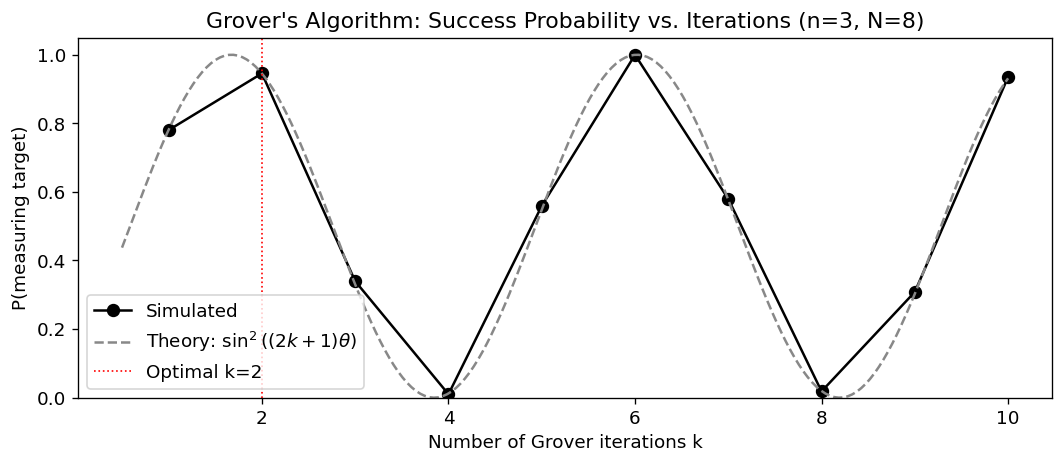


Key insight: overshot iterations REDUCE probability — Grover is not monotone.
Apply too many times and the state rotates past |ω⟩ back toward |ω⊥⟩.
The sinusoidal behaviour confirms the geometric (rotation) picture.


In [6]:
# ── Show how probability evolves with iterations ────────────────────
n, target = 3, '101'
N = 2 ** n
max_iters = 10

probs = []
for k in range(1, max_iters + 1):
    qc = grover_circuit(n, target, iterations=k)
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=4096).result()
    counts = result.get_counts()
    probs.append(counts.get(target, 0) / 4096)

# Theoretical curve: P(k) = sin²((2k+1)·arcsin(1/√N))
theta = np.arcsin(1 / np.sqrt(N))
k_range = np.linspace(0.5, max_iters, 200)
theory = np.sin((2 * k_range + 1) * theta) ** 2

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, max_iters + 1), probs, 'o-', color='#000', ms=7, label='Simulated')
ax.plot(k_range, theory, '--', color='#888', lw=1.5, label='Theory: $\sin^2((2k+1)\\theta)$')
ax.axvline(int(np.pi / 4 * np.sqrt(N)), color='red', lw=1, ls=':', label=f'Optimal k={int(np.pi/4*np.sqrt(N))}')
ax.set_xlabel("Number of Grover iterations k")
ax.set_ylabel("P(measuring target)")
ax.set_title(f"Grover's Algorithm: Success Probability vs. Iterations (n={n}, N={N})")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('grover_iterations.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey insight: overshot iterations REDUCE probability — Grover is not monotone.")
print("Apply too many times and the state rotates past |ω⟩ back toward |ω⊥⟩.")
print(f"The sinusoidal behaviour confirms the geometric (rotation) picture.")


In [7]:
# ── Scaling: how many iterations vs N? ─────────────────────────────
print(f"{'n qubits':>10} | {'N = 2^n':>10} | {'Classical avg':>14} | {'Grover iters':>13} | {'Speedup':>8}")
print("-" * 62)
for n in [2, 3, 4, 5, 6, 8, 10, 16, 20, 30]:
    N = 2 ** n
    classical = N // 2
    grover = max(1, int(np.pi / 4 * np.sqrt(N)))
    speedup = classical / grover
    print(f"{n:>10} | {N:>10,} | {classical:>14,} | {grover:>13,} | {speedup:>7.0f}×")


  n qubits |    N = 2^n |  Classical avg |  Grover iters |  Speedup
--------------------------------------------------------------
         2 |          4 |              2 |             1 |       2×
         3 |          8 |              4 |             2 |       2×
         4 |         16 |              8 |             3 |       3×
         5 |         32 |             16 |             4 |       4×
         6 |         64 |             32 |             6 |       5×
         8 |        256 |            128 |            12 |      11×
        10 |      1,024 |            512 |            25 |      20×
        16 |     65,536 |         32,768 |           201 |     163×
        20 |  1,048,576 |        524,288 |           804 |     652×
        30 | 1,073,741,824 |    536,870,912 |        25,735 |   20862×


## Key Takeaways

1. **Oracle + Diffusion** is the Grover iteration. Each step rotates the state by $2\theta$ in the $\{|\omega\rangle, |\omega^\perp\rangle\}$ plane.
2. **Optimal iterations**: $k^* \approx \frac{\pi}{4}\sqrt{N}$. Too few → low probability; too many → wraps past the target.
3. **Quadratic speedup**: $O(N) \to O(\sqrt{N})$. Provably optimal — no quantum algorithm can search faster.
4. **Generalisation**: works for $M$ marked items with $O(\sqrt{N/M})$ iterations.
5. **Impact**: Grover weakens (but does not break) symmetric cryptography. AES-256 has $2^{256}$ keys; Grover reduces this to $2^{128}$ effective security. Solution: double the key length.
6. **Amplitude amplification** is the general version: any algorithm with success probability $p$ can be boosted to near-certainty in $O(1/\sqrt{p})$ applications.
